# Modelos de regresión Bayesianos

Este trabajo se divide en dos partes fundamentales. En la primera, se lleva a cabo un análisis electoral de la alcaldía de Bogotá, con el objetivo de estimar a nivel poblacional, la proporción de votos que recibirían los candidatos a dicha alcaldía, utilizando como muestra los datos recopilados por la encuestadora Invamer, dado que fue la que obtuvo menor error en las estimación de la proporción de votos de los candidatos a la alcaldía de Bogotá.

La segunda parte se centra en la construcción de un modelo predictivo para
la medida de progresividad en 442 pacientes que sufren de diabetes. Para esto se proponen 4 modelos con la finalidad de seleccionar el modelo que minimiza el Error Absoluto Medio (EAM). Los dos primeros modelos consideran la previa unitaria y la previa g, mientras que los dos últimos incorporan un modelo mediante regresión rígida y otro con errores correlacionados. Por otra parte, se validará la bondad de ajuste de cada modelo usando como estadístico de prueba la media, así como los criterios de información como el DIC. En ambas apartados emplearemos el muestreador de Gibbs y Metropolis para la simulación de la distribución posterior.

## Análisis electoral alcaldía de Bogotá


La Silla Vacía evaluó el desempeño de las encuestadoras en las elecciones regionales de 2023 en las cinco ciudades principales de Colombia. En el artículo, se compara las predicciones de las encuestadoras con los resultados reales de las elecciones y analiza la precisión de cada encuestadora. En este analisis, se encontró que la encuestadora \textbf{Invamer} fue la que tuvo \textit{menor error total} para la ciudad de Bogotá (Restrepo, 2024).

Invamer llevó a cabo una encuesta entre el 17 y el 23 de octubre de 2023 para Noticias Caracol, Blu Radio y El Espectador, con el propósito de evaluar la intención de voto en las elecciones para alcaldes del 2023 en Bogotá, Medellín, Cali, Barranquilla y Bucaramanga. En Bogotá, se encuestaron 1200 personas (entre hombres y mujeres) de 18 años en adelante, de diversos estratos socioeconómicos, con derecho a voto y residencia en la ciudad. Las encuestas se realizaron personalmente en los hogares utilizando tablets, y se empleó un tarjetón para las preguntas sobre intención de voto. Los resultados específicos se encuentran detallados en la Tabla de acontinuación.(Invamer, 2023).

| **Candidato**     | **Cantidad** | **Proporción** |
|-------------------|--------------|----------------|
| C. F. Galán       | 493          | 0.411          |
| G. Bolivar        | 257          | 0.214          |
| J. D. Oviedo      | 227          | 0.189          |
| D. Molano         | 48           | 0.040          |
| R. Lara           | 41           | 0.034          |
| J. L. Vargas      | 38           | 0.032          |
| J. E. Robledo     | 28           | 0.023          |
| N. Ramos          | 11           | 0.009          |
| R. A. Quintero    | 3            | 0.003          |
| Voto en Blanco    | 54           | 0.045          |
| **Total**         | **1200**     | **1.000**      |

Invamer utilizó un tipo particular de muestreo aleatorio simple sin reemplazo (ver "Opinión Alcaldes 2023", 2023) es factible considerar la muestra como una muestra aleatoria simple con reemplazo (IID). Esto se debe a que el tamaño total de la muestra es significativamente pequeño en comparación con el tamaño del Universo. El enfoque primordial de este apartado, tanto en el ámbito científico como político, reside en la estimación de la proporción de votos de cada candidato a nivel poblacional, utilizando los datos suministrados por Invamer.

### Ajuste del modelo

In [3]:
import pandas as pd
import numpy as np
import math as mt
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import arviz as az
import random

In [2]:
ns = np.array([493, 257, 227, 48, 41, 38, 28, 11, 3, 54])
thetas = np.array([0.411, 0.214, 0.189, 0.040, 0.034, 0.032, 0.023, 0.009, 0.003, 0.045])
n = ns.sum()
a = b = 1
k = len(ns)

In [3]:
#Expresión de la log distribución de log de alpha
def dgamma1(r, t):
    return (np.exp(r) - 1)*np.sum(np.log(t)) + r - np.exp(r) + mt.lgamma(10*np.exp(r)) - 10*mt.lgamma(np.exp(r))

In [4]:
#Valor incial
theta = thetas
gama = 0.3

#Parámetro de ajuste
delta = 1.5

B = 101000 #total iteraciones
C = 1000 #calentamiento
A = 10 #Amplitud del muestreo

#Almacenamiento
MC = pd.DataFrame(np.empty((int((B-C)/A), k+1)))
LL = pd.DataFrame(np.empty((int((B-C)/A), 1)))
ind = 0
ac = 0
np.random.seed(1)

for b in range(0, B):
    #Actualización de theta
    theta = stats.dirichlet.rvs(alpha = np.repeat(np.exp(gama), k) + ns, size=1).flatten().tolist()

    #Actualización de alpha - metropolis
    gamaI = stats.norm.rvs(size = 1, loc = gama, scale = np.sqrt(delta))
    #Tasa de aceptación
    logr = dgamma1(gamaI, theta) - dgamma1(gama, theta)
    if stats.uniform.rvs(size = 1) < np.exp(logr):
        gama = gamaI
        ac = ac + 1
    if b >= C and b % A == 0:
        LL.iloc[ind, 0] = np.sum(stats.multinomial.logpmf(x = ns, p = theta, n = n))
        MC.iloc[ind, :] = theta + np.exp(gama).tolist()
        ind += 1

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_9788\679816448.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return (np.exp(r) - 1)*np.sum(np.log(t)) + r - np.exp(r) + mt.lgamma(10*np.exp(r)) - 10*mt.lgamma(np.exp(r))


In [5]:
#Diagnóstico de convergencia
def emc(x):
    neff = az.ess(x.to_numpy())
    return np.std(x)/neff
def cvmc(x):
    return 100*np.abs(emc(x)/np.mean(x))
def cv(x):
    return 100*np.abs(np.std(x)/np.mean(x))

pd.DataFrame({'CVMC':np.transpose(MC.apply(cvmc, axis = 0)), 'EMC':np.transpose(MC.apply(emc, axis = 0))})

,CVMC,EMC
0,0.000376,1.538692e-06
1,0.000575,1.227445e-06
2,0.000604,1.139642e-06
3,0.001387,5.587870e-07
4,0.001538,5.320484e-07
5,0.001599,5.122261e-07
6,0.001832,4.359068e-07
7,0.002848,2.746875e-07
8,0.005290,1.613560e-07
9,0.001303,5.895798e-07


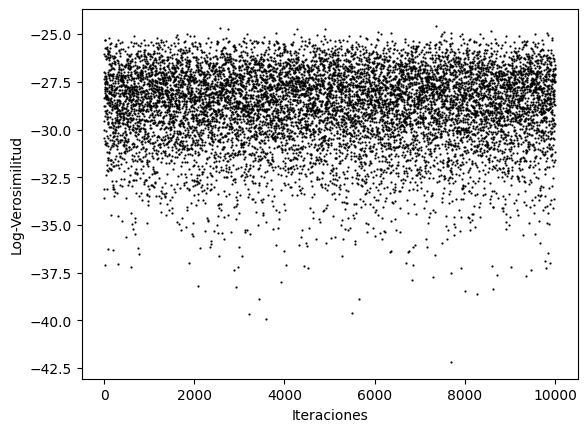

In [7]:
sns.scatterplot(x = range(1,10001), y = LL.iloc[:,0], facecolor = 'black', edgecolor = 'black', s=2)
plt.xlabel('Iteraciones')
plt.ylabel('Log-Verosimilitud')
plt.show()

In [8]:
#Criterio de información
l1 = np.sum(stats.multinomial.logpmf(x = ns, p = np.array(MC.iloc[:,0:10].apply(np.mean, axis = 0)), n = n))
pDIC = 2*(l1 - np.mean(LL[0]))
DIC = -2*l1 + 2*pDIC
DIC

66.42499937791273

Ateniendo al objetivo de este apartado, en el **Apéndice** se encuentra la información del modelo Bayesiano con el que se va a estimar la proporción de votos. Así pues, ajustado el modelo Bayesiano por medio de el muestreador de Gibbs y Metropolis se obtuvieron los siguientes resultados:

In [9]:
#Inferencia
phi = np.array(MC.iloc[:,0:10].apply(np.mean, axis = 0))
IC = MC.apply(lambda x: np.percentile(x, q=[2.5, 97.5]))
Resul = pd.DataFrame({'Estimacion': phi*100, 'CV %': np.array(MC.iloc[:,0:10].apply(cv, axis = 0)),
    'IC Inf':list(IC.iloc[0,0:10]*100), 'IC Sup':list(IC.iloc[1,0:10]*100),
    'Real':[49.2, 18.71, 20.10, 2.14, 2.28, 1.02, 1.13, 0.51, 0.16, 4.87],
    'Name': ['C. F. Galán', 'G. Bolivar', 'J. D. Oviedo', 'D. Molano',
               'R. Lara', 'J. L. Vargas', 'J. E. Robledo', 'N. Ramos',
               'R. A. Quintero', 'Voto en Blanco']})
Resul

,Estimacion,CV %,IC Inf,IC Sup,Real,Name
0,40.910390,3.444184,38.188318,43.667869,49.20,C. F. Galán
1,21.354989,5.523799,19.129219,23.692244,18.71,G. Bolivar
2,18.871235,5.941226,16.719524,21.098447,20.10,J. D. Oviedo
3,4.028790,14.085622,2.987887,5.188536,2.14,D. Molano
4,3.460387,15.072478,2.515998,4.556524,2.28,R. Lara
5,3.202792,15.816223,2.280399,4.257289,1.02,J. L. Vargas
6,2.378813,18.366383,1.590340,3.327395,1.13,J. E. Robledo
7,0.964420,29.204445,0.492282,1.585860,0.51,N. Ramos
8,0.305009,51.892459,0.074475,0.680964,0.16,R. A. Quintero
9,4.523174,13.197399,3.416394,5.749672,4.87,Voto en Blanco


La información de la Tabla anterior presenta la estimación de la proporción de votos para los candidatos Carlos Fernando Galán, Gustavo Bolivar y Juan Daniel Oviedo. Se observa un coeficiente de variación (CV) bajo y una amplitud en los intervalos de credibilidad moderada, lo que nos lleva a concluir que existe una baja incertidumbre en las estimaciones.

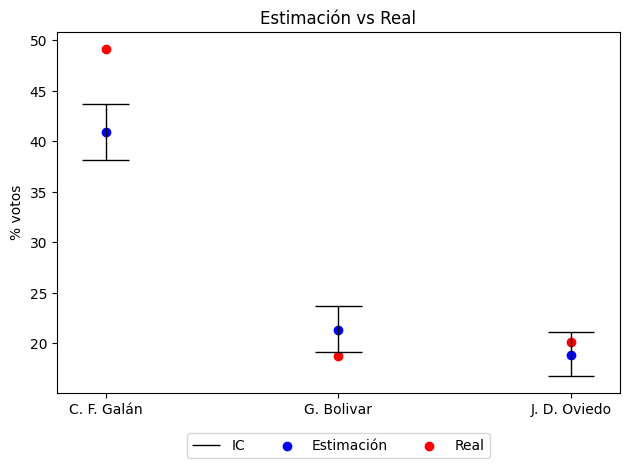

In [10]:
Resul_subset = Resul.head(3)
# Crear el gráfico de dispersión con líneas verticales y horizontales
plt.vlines(x=np.arange(len(Resul_subset)), ymin=Resul_subset['IC Inf'], ymax=Resul_subset['IC Sup'],
           color='black', linestyle='-', linewidth=1, label='IC')
for i, (lower, upper) in enumerate(zip(Resul_subset['IC Inf'], Resul_subset['IC Sup'])):
    plt.hlines(y=lower, xmin=i - 0.1, xmax=i + 0.1, color='black', linestyle='-', linewidth=1)
    plt.hlines(y=upper, xmin=i - 0.1, xmax=i + 0.1, color='black', linestyle='-', linewidth=1)
plt.scatter(x=np.arange(len(Resul_subset)), y=Resul_subset['Estimacion'], color='blue', label='Estimación', marker='o')
plt.scatter(x=np.arange(len(Resul_subset)), y=Resul_subset['Real'], color='red', label='Real', marker='o')

# Ajustar el aspecto del gráfico
plt.xticks(np.arange(len(Resul_subset)), Resul_subset['Name'])
plt.xlabel('')
plt.ylabel('% votos')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=3)
plt.title('Estimación vs Real')
plt.tight_layout()
plt.show()

En la Figura anterior se comparan la estimación de la proporción de votos con las que se obtuvieron en los resultados de las elecciones el pasado 29 de Octubre de 2023. Se observa que para el candidato Galán y Oviedo se subestimó la proporción de votos, mientras que para el candidato Bolivar se sobrestimó. Sin embargo se logró estimar que el ganador de la alcaldía de Bogotá iba a ser el candidato Galán. Cabe mencionar que el intervalo de credibilidad para el candidato Oviedo contiene el valor real, contrario a los demás candidatos.

## Análisis de diabetes

Considere la base de datos sobre diabetes proporcionada en la Sección 9.3 de \cite{Holf}. En este conjunto de datos se relaciona 10 medidas iniciales $x_1, \ldots, x_{10}$ en un grupo de 442 pacientes diabéticos, así como una medida de progresión de la enfermedad $y$ tomada un año después de las medidas iniciales. Los datos pueden se pueden descargar de este [enlace](http://www2.stat.duke.edu/~pdh10/FCBS/Inline/) en los archivos llamados $yX.diabetes.train$ y $yX.diabetes.test$. 


El objetivo principal es construir un modelo predictivo para $y$ basado en $x_1, \ldots, x_{10}$ (donde tanto $y$ como las $x_j$ están estandarizadas). Además, se sospecha que la relación entre $y$ y las $x_j$ podría no ser lineal, por lo tanto se añaden termino de segundo orden en la forma de la $x_j^2$ y $x_{j}x_{k}$. En este contexto, las variables regresoras incluyen diez efectos principales $x_j$,  45 interacciones $x_jx_k$, y nueve términos cuadráticos $x_{j}^2$ (no es necesario incluir $x_{2}^2$ en el modelo debido a que $x_2 = $ sexo es binario, por lo que $x_{2}^2 = x_2$). Esto resulta en un total de $p = 64$ variables regresoras. No se considera el intercepto ya que las variables se encuentran estandarizadas.

Para la construcción del modelo predictivo se proponen 4 modelos con la finalidad de seleccionar el modelo con mayor capacidad predictiva, es decir, elegir el modelo que minimiza el Error Absoluto Medio (EAM). Para lograr esto, el conjunto de datos está divido en dos partes: entrenamiento y testeo. De esta manera se ajustarán los modelos con el conjunto de entrenamiento y se validara en los conjunto de testeo.

### Modelos Bayesianos y su estrucura jerarquica

Consideraremos 4 modelos de regresión Bayesianos. Para los primeros 3 modelos consideremos la misma distribución muestral dada por:

$$ \boldsymbol{y} \mid \mathbf{X}, \boldsymbol{\beta}, \sigma^2 \sim \textbf{N}_{n}(\mathbf{X}\boldsymbol{\beta}, \sigma^2\mathbf{I}_{n}) $$

Con $\boldsymbol{y}_{(n \times 1)}$ es el vector de respuesta, $\boldsymbol{\beta}_{(p\times 1)}$ vector de parámetros a estimar, $\mathbf{X}_{(n \times p)}$ matriz de diseño y $\mathbf{I}_n$ matriz identidad de \(n\times n\). Además, para los primeros 2 modelos consideraremos la distribución previa dada por:

$$
\begin{align*}
    \boldsymbol{\beta} &\sim \textsf{N}_p(\boldsymbol{\beta}_0, \mathbf{\Sigma}_0) \\
    \sigma^2  &\sim \textsf{GI}\left( \tfrac{\nu_0}{2}, \tfrac{\nu_0\sigma^2_0}{2} \right)  
\end{align*}
$$

1. **Previa unitaria:** esta propone usar los datos para asignarles valores a los hiperparámetros. De manera que:

   $$ \boldsymbol{\beta}_0 = \hat{\boldsymbol{\beta}}_{\text{ols}}, \quad \mathbf{\Sigma}_0 = n\,\hat\sigma^2_{\text{ols}} (\mathbf{X}^{\textsf{T}}\mathbf{X})^{-1}, \quad \nu_0 = 1, \quad \sigma^2_0 = \hat\sigma^2_{\text{ols}}. $$

   Donde **ols** hace referencia a Odinary Least Squares (Mínimos Cuadrados Ordinarios).

2. **Previa g:** al igual que la previa unitaria, propone usar los datos para asignar valores a los hiperparámetros. Lo que las diferencia es que en este caso $\boldsymbol{\beta}$ depende del valor de $\sigma^2$. De manera que:

   $$ \boldsymbol{\beta}_0 =\boldsymbol{0}_p, \quad \mathbf{\Sigma}_0 = \text{g}\sigma^2(\mathbf{X}^{\textsf{T}}\mathbf{X})^{-1} $$

   En $\mathbf{\Sigma}_0$ se observa la dependencia de $\boldsymbol{\beta}$ en $\sigma^2$. Los parámetros para la distribución de $\sigma^2$ se mantienen como en la previa unitaria.

3. **Regresión rígida:** Consideremos la siguiente distribución previa:

   $$
   \begin{align*}
        \boldsymbol{\beta} &\sim \textsf{N}_p\left(\boldsymbol{0}_p, \tfrac{\sigma^2}{\lambda}\mathbf{I}_p\right), \\
        \sigma^2 &\sim \textsf{GI}\left( \tfrac{\nu_0}{2}, \tfrac{\nu_0\sigma^2_0}{2} \right), \\
        \lambda &\sim \textsf{G}(a_\lambda , b_\lambda)
   \end{align*}
   $$

   Con $\nu_0 = 1$, $\sigma_0^2 = \hat{\sigma}^2_{\text{OLS}}$, $a_\lambda = 1$ y $b_\lambda = 2$.

4. **Regresión con errores correlacionados:** consideramos la siguiente distribución muestral:

   $$ \boldsymbol{y}\mid\mathbf{X},\boldsymbol{\beta},\sigma^2,\rho \sim \textsf{N}_{n}(\mathbf{X}\boldsymbol{\beta},\sigma^2\mathbf{C}_\rho) $$

   Siendo $\mathbf{C}_\rho$ es una matriz con estructura autoregresiva de primer orden:

   $$
   \mathbf{C}_\rho =
   \left[\begin{array}{ccccc}
       1 & \rho & \rho^{2} & \cdots & \rho^{n-1} \\
       \rho & 1 & \rho & \cdots & \rho^{n-2} \\
       \rho^{2} & \rho & 1 & \cdots & \rho^{n-3} \\
       \vdots & \vdots & \vdots & \ddots & \vdots \\
       \rho^{n-1} & \rho^{n-2} & \rho^{n-3} & \cdots & 1
   \end{array}\right]
   $$

   Por otro lado, se propone la siguiente distribución previa:

   $$
   \begin{align*}
        \beta_j &\stackrel{\text{iid}}{\sim}\textsf{N}(0, \tau^2_0), \\
        \sigma^2 &\sim \textsf{GI}\left( \tfrac{\nu_0}{2}, \tfrac{\nu_0\sigma^2_0}{2} \right), \\
        \rho &\sim \textsf{U}(a_\rho , b_\rho)
   \end{align*}
   $$

   Con $\tau_0^2 = 50$, $\nu_0 = 1$, $\sigma^2 =\sigma^2_{\text{ols}}$, $a_\rho = 0$ y $b_\rho = 1$.


Los 4 modelos descritos anteriormente, se ajustarán usando el muestreador de Gibss y el algoritmo de Metropolis, usando 21.000 iteraciones, con 1.000 muestras de calentamiento y un muestreo sistemático con una amplitud de 2.



## Ajuste de los modelos

In [5]:
import os
os.chdir('C:\\Users\\aleja\\Downloads\\Juan Daniel')
YX_test = pd.read_excel('YX.test.xlsx')
YX_train = pd.read_excel('YX.train.xlsx')
X_test = YX_test.iloc[0:65,1:66].values
Y_test = YX_test.iloc[0:65,0].values
Y_train = YX_train.iloc[0:342,0].values
X_train = YX_train.iloc[0:342,1:66].values
n_train = X_train.shape[0]
p = X_train.shape[1]

### Previa unitaria

In [6]:
#Parametros de OLS
beta_ols = np.linalg.inv((X_train.T @ X_train)) @ X_train.T @ Y_train
sig2_ols = np.sum((Y_train - (X_train @ beta_ols))**2)/(n_train - p)

#Hiperparámetros
B0 = beta_ols
Sig20 = n_train*sig2_ols*np.linalg.inv(X_train.T @ X_train)
nu0 = 1
s20 = sig2_ols

#Algunos términos
s = np.linalg.inv(Sig20)
sb = s @ B0
xs = X_train.T @ X_train

#Valores iniciales
np.random.seed(1)
Betas = stats.multivariate_normal.rvs(mean = B0, cov = Sig20, size = 1)
np.random.seed(1)
Sigma = stats.invgamma.rvs(size = 1, a = nu0*0.5, loc =nu0*s20*0.5 )

B = 21000
C = 1000
A = 2
MC1 = pd.DataFrame(np.empty((int((B-C)/A), p+1)))
LL1 = pd.DataFrame(np.empty((int((B-C)/A), 1)))
ind = 0

np.random.seed(1)
for b in range(0, B):
    Vbeta = np.linalg.inv(s + 1/Sigma*xs)
    Betas = stats.multivariate_normal.rvs(mean = Vbeta @ (sb + 1/Sigma*X_train.T @ Y_train),
                                          cov = Vbeta, size = 1)
    Sigma = stats.invgamma.rvs(size = 1, a = 0.5*(nu0 + n_train), scale = 0.5*np.sum((Y_train - X_train @ Betas)**2))
    if b >= C and b % A == 0:
        LL1.iloc[ind,0] = np.sum(stats.multivariate_normal.logpdf(x = Y_train, mean = X_train@Betas,
                                                               cov = Sigma.item()))
        MC1.iloc[ind,:] = Betas.tolist() + Sigma.tolist()
        ind += 1

### Previa G

In [7]:
#Hiperparametros
g = n_train
S20 = sig2_ols
nu0 = 1

#Valores iniciales
IX = np.linalg.inv(X_train.T @ X_train) @ X_train.T
Vbeta = (g/(g+1))*np.linalg.inv(X_train.T @ X_train)
Ebeta = (g/(g+1))*IX @ Y_train
SSSg = Y_train.T @ (1*np.eye(n_train) - (g/(g+1))*X_train @ IX) @ Y_train
MC2 = np.empty((10000, p+1))
LL2 = np.empty((10000, 1))
np.random.seed(1)
for b in range(0, 10000):
    sig2_mc = stats.invgamma.rvs(size = 1, a = 0.5*(nu0 + n_train), scale = 0.5*(nu0*S20 + SSSg)).item()
    beta_mc = stats.multivariate_normal.rvs(size = 1, mean = Ebeta, cov = Vbeta*sig2_mc)
    LL2[b,0] = np.sum(stats.multivariate_normal.logpdf(x = Y_train, mean = X_train@beta_mc, cov = sig2_mc))
    MC2[b,:] = beta_mc.tolist() + [sig2_mc]

### Regresión rígida

In [8]:
#Hiperparámetros
a = 1
b = 2
sig0 = sig2_ols
nu0 = 1

#Valores inciales
S2 = stats.invgamma.rvs(size = 1, a=0.5*nu0, scale = nu0*sig0*0.5).item()
lamda = stats.gamma.rvs(size = 1, a = 1, scale = 1/2).item()
Beta = stats.multivariate_normal.rvs(size = 1, mean=np.zeros(p), cov=(S2/lamda)*np.eye(p))

B = 21000
Ca = 1000
A = 2
ind = 0
MC3 = np.empty((int((B-Ca)/A), p+2))
LL3 = np.empty((int((B-Ca)/A), 1))
XtX = X_train.T@X_train
XtY = X_train.T@Y_train
for b in range(0, B):
    var = np.linalg.inv(XtX + lamda*np.eye(p))
    Beta = stats.multivariate_normal.rvs(size = 1, mean = var@XtY, cov = S2*var)
    lamda = stats.gamma.rvs(size = 1, a = a + 0.5*p, scale = 1/(b + 0.5*(Beta.T @ Beta)/S2)).item()
    S2 = stats.invgamma.rvs(size = 1, a = 0.5*(nu0 + p + n_train), 
                            scale = (nu0*sig0 + lamda*Beta.T @ Beta + np.sum((Y_train - X_train@Beta)**2))*0.5).item()

    #Almacenamiento
    if b >= Ca and b % A == 0:
        LL3[ind,0] = np.sum(stats.multivariate_normal.logpdf(x = Y_train,
                                                             mean = X_train@Beta, cov = S2))
        MC3[ind,:] = Beta.flatten().tolist() + [S2, lamda]
        ind += 1


### Errores correlacionados

In [11]:
#Previa
nu0 = 1
s20 = sig2_ols
a = 0
b = 1
tao2 = 50
Sigma_0 = np.diag(1/tao2 * np.ones(p))

#Base construcción de la matriz de correlación
D = np.abs(np.subtract.outer(np.arange(1, n_train + 1), np.arange(1, n_train + 1)))
delta = 0.35

#Valores iniciales
Beta = beta_ols
S2 = sig2_ols
rho = stats.uniform.rvs(size = 1).item()
ac = 0

B = 21000
Ca = 1000
A = 2

MC4 = np.empty((int((B-Ca)/A), p+2))
LL4 = np.empty((int((B-Ca)/A), 1))
np.random.seed(1)
ind = 0
for b in range(0, B):
    C = np.power(rho, D)
    invC = np.linalg.inv(C)
    #varianza de beta
    V_beta = np.linalg.inv(Sigma_0 + 1/S2*X_train.T @ invC @ X_train)
    Beta = stats.multivariate_normal.rvs(size = 1,
                                         mean = V_beta @ (1/S2*X_train.T @
                                                          invC @ Y_train),
                                         cov = V_beta)

    #Simular sigma^2
    Beta = Beta.reshape(-1, 1)
    S2 = stats.invgamma.rvs(size = 1, a =  0.5*(nu0 + n_train),
                            scale = 0.5*(nu0*s20 +
                                         np.transpose(Y_train.reshape(-1,1) -
                                                      X_train@Beta) @invC@
                                                       (Y_train.reshape(-1,1) -
                                                        X_train@Beta)).item()).item()

    #Simulacion de rho - metropolis
    rhoP = np.abs(stats.uniform.rvs(size=1, loc = rho - delta,
                                    scale=rho + delta)).item()
    rhoP = min(rhoP, 2-rhoP)

    #Determinantes
    signo_rhoP, logdet_rhoP = np.linalg.slogdet(np.power(rhoP, D))
    signo_rho, logdet_rho = np.linalg.slogdet(np.power(rho, D))

    logdetrhoP = signo_rhoP * logdet_rhoP
    logdetrho = signo_rho * logdet_rho

    #Tasa de aceptación
    log_r = -0.5*((logdetrhoP - logdetrho) +
                  np.trace((Y_train-X_train@Beta)@np.transpose(Y_train-X_train@Beta)@
                   (np.linalg.inv(np.power(rhoP, D)) -np.linalg.inv(np.power(rho, D))))/S2)
    if (stats.uniform.rvs(size = 1).item() < np.exp(log_r.item())):
        rho = rhoP
        ac += 1

    #Almacenamiento
    if b >= Ca and b % A == 0:
        LL4[ind,0] = np.sum(stats.multivariate_normal.logpdf(x = Y_train,
                                                             mean = (X_train@Beta.flatten()), cov = S2*np.power(rho, D)))
        MC4[ind,:] = Beta.flatten().tolist() + [S2, rho]
        ind += 1

C:\Users\aleja\AppData\Local\Temp\ipykernel_16000\2027730376.py:62: RuntimeWarning: overflow encountered in exp
  if (stats.uniform.rvs(size = 1).item() < np.exp(log_r.item())):


## Diagnóstico de los modelos

### Convergencia

In [20]:
#Diagnóstico de convergencia
def emc(x):
    neff = az.ess(x)
    return np.std(x)/neff
def cvmc(x):
    return 100*np.abs(emc(x)/np.mean(x))
def cv(x):
    return 100*np.abs(np.std(x)/np.mean(x))

In [ ]:
#Coeficiente de Variación de Monte Carlo - CVMC y Error de Monte Carlo - EMC para los tres modelos
df1 = pd.DataFrame({'CVMC% M1': np.apply_along_axis(cvmc, axis = 0, arr = MC1), 'EMC':np.apply_along_axis(emc, axis = 0, arr = MC1)})
df2 = pd.DataFrame({'CVMC%': np.apply_along_axis(cvmc, axis = 0, arr = MC3), 'EMC':np.apply_along_axis(emc, axis = 0, arr = MC3)})
df3 = pd.DataFrame({'CVMC%': np.apply_along_axis(cvmc, axis = 0, arr = MC4), 'EMC':np.apply_along_axis(emc, axis = 0, arr = MC4)})

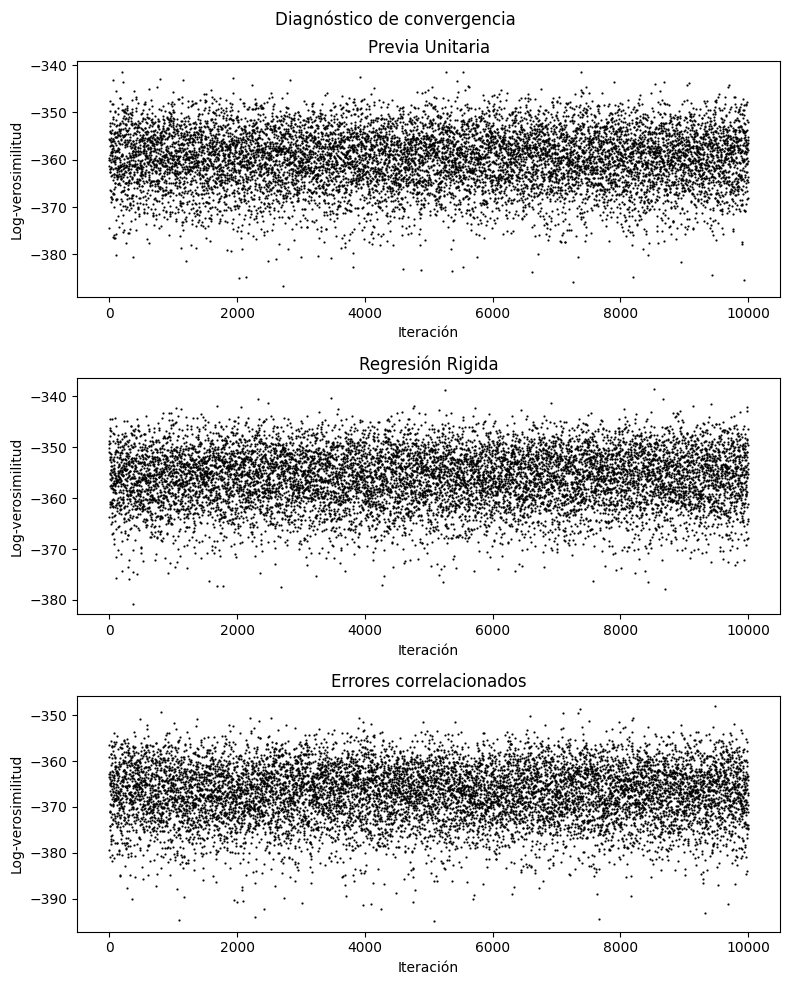

In [ ]:
titulos = ['Previa Unitaria', 'Regresión Rigida', 'Errores correlacionados']
datos = [LL1[0], LL3[:, 0], LL4[:, 0]]
fig, axs = plt.subplots(nrows=3, figsize=(8, 10))

for dato, ax, titulo in zip(datos, axs, titulos):
    sns.scatterplot(x=range(0, 10000), y=dato, ax=ax, facecolor='black', edgecolor='black', s=2)
    ax.set(xlabel='Iteración', ylabel='Log-verosimilitud')
    ax.set_title(titulo)
plt.tight_layout()
plt.show()

### Criterios de información

In [35]:
#Previa Unitaria
log1 = np.sum(stats.multivariate_normal.logpdf(x = Y_train, mean = X_train @ MC1.iloc[:,0:64].mean(), cov = np.mean(MC1.iloc[:,64])))
pDIC1 = 2*(log1 - np.mean(LL1[0]))
DIC1 = -2*log1 + 2*pDIC1
DIC1

#Previa G
log2 = np.sum(stats.multivariate_normal.logpdf(x = Y_train, mean = X_train @ np.mean(MC2[:,0:64], axis = 0), cov = np.mean(MC2[:,64])))
pDIC2 = 2*(log2 - np.mean(LL2[0]))
DIC2 = -2*log2 + 2*pDIC2

#Regresión rigida
log3 = np.sum(stats.multivariate_normal.logpdf(x = Y_train, mean = X_train @ np.mean(MC3[:,0:64], axis = 0), cov = np.mean(MC3[:,64])))
pDIC3 = 2*(log3 - np.mean(LL3[0]))
DIC3 = -2*log3 + 2*pDIC3


#Errores correlacinados
log4 = np.sum(stats.multivariate_normal.logpdf(x = Y_train, mean = X_train @ np.mean(MC4[:,0:64], axis = 0),
                                               cov = np.mean(MC4[:,64])*np.power(np.mean(MC4[:,65]), D)))
pDIC4 = 2*(log4 - np.mean(LL4[0]))
DIC4 = -2*log4 + 2*pDIC4

#Criterios de Información
pd.DataFrame({"Modelo": ['M1', 'M2', 'M3', 'M4'], 'DIC':[DIC1, DIC2, DIC3, DIC4]})


,Modelo,DIC
0,M1,784.116584
1,M2,761.648571
2,M3,755.073179
3,M4,754.958366


### Bondad de ajuste del modelo

In [36]:
BA = np.empty((10000, 4))
np.random.seed(1)
for i in range(0,10000):
    y1 = np.mean(stats.multivariate_normal.rvs(size = 1, mean = X_train@MC1.iloc[i,0:64], cov = MC1.iloc[i,64]))
    y2 = np.mean(stats.multivariate_normal.rvs(size = 1, mean = X_train @ MC2[i,0:64], cov = MC2[i,64]))
    y3 = np.mean(stats.multivariate_normal.rvs(size = 1, mean = X_train @ MC3[i,0:64], cov = MC3[i,64]))
    y4 = np.mean(stats.multivariate_normal.rvs(size = 1, mean = X_train@MC4[i,0:64], cov = MC4[i,64]*np.power(MC4[i,65], D)))
    BA[i, :] = [y1, y2, y3, y4]

In [40]:
titulos

['Previa Unitaria',
 'Previa G',
 'Previa G',
 'Regresión Rigida',
 'Errores correlacionados']

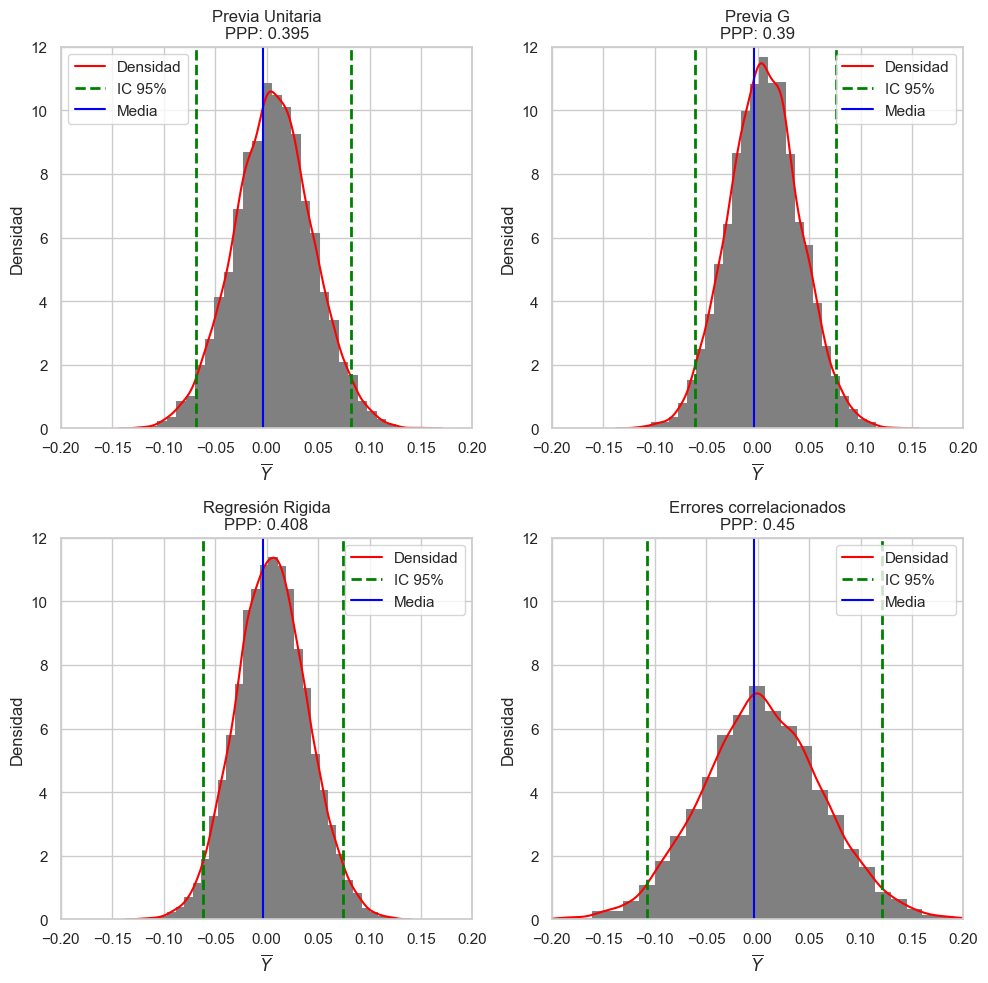

In [42]:
titulos.insert(1, 'Previa G')
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
axs = axs.flatten()
sns.set_theme(style="whitegrid")

for i in range(4):
    BAi = BA[:, i]
    ax = axs[i]
    
    sns.histplot(BAi, bins=30, color='gray', edgecolor='gray', facecolor = 'gray', stat='density', ax=ax)
    sns.kdeplot(BAi, color='red', label='Densidad', ax=ax)
    
    ax.axvline(np.percentile(BAi, 2.5), color='green', linestyle='dashed', linewidth=2, label='IC 95%')
    ax.axvline(np.percentile(BAi, 97.5), color='green', linestyle='dashed', linewidth=2)
    ax.axvline(np.mean(Y_train), color='blue', linewidth=1.5, label='Media')
    
    ax.set_ylabel('Densidad')
    ax.set_xlabel(r'$\overline{Y}$')
    ax.set_title(f'{titulos[i]}\nPPP: {round(np.mean(BAi < np.mean(Y_train)), 3)}')
    ax.set_xlim(-0.2, 0.2)
    ax.set_ylim(0, 12)
    ax.legend()

plt.tight_layout()
plt.show()

Así que para los 4 modelos la media está siendo estimada correctamente, dado que el PPP está cercano a 0.5 además que la estadística observada (Est. Obser.) se encuentra dentro de los Intervalos de Confianza (IC). 

## Resultados

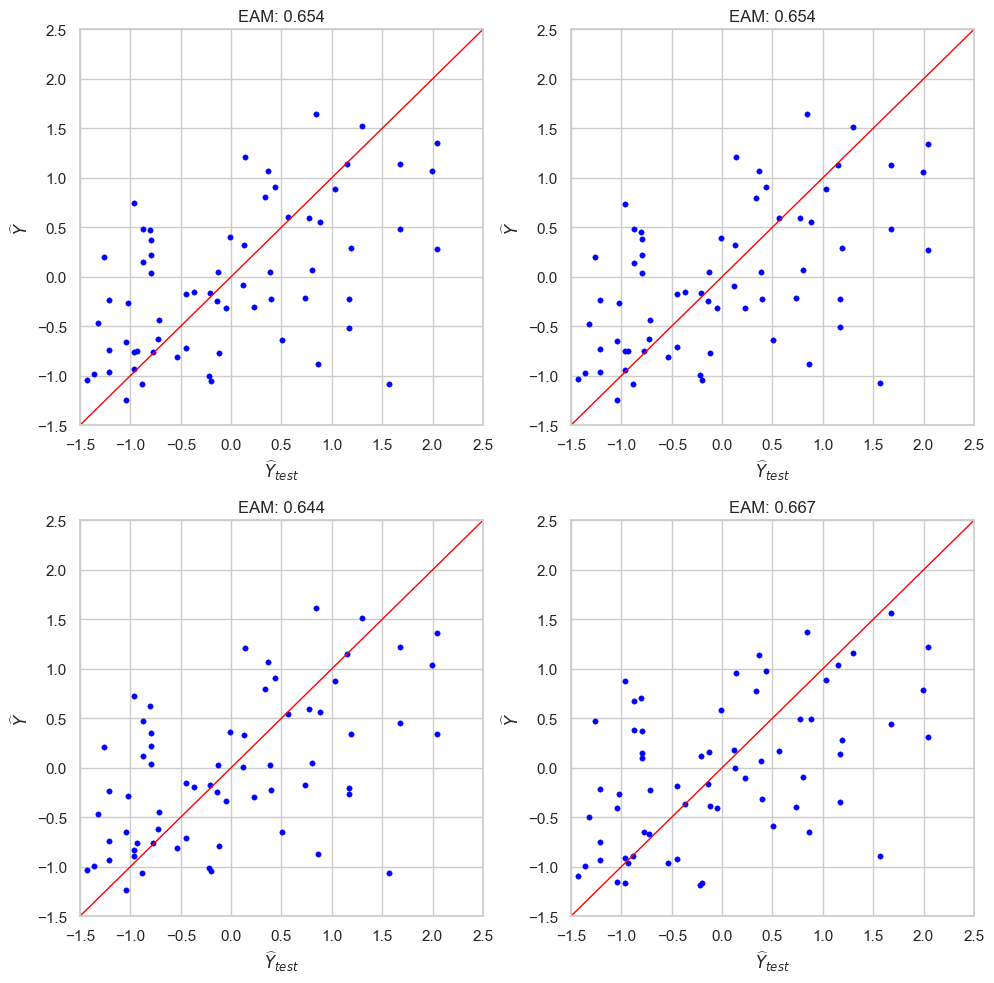

In [38]:
# Previa Unitaria
Yhat_test1 = X_test @ MC1.iloc[:, 0:64].mean()
Epsilon1 = np.mean(np.abs(Y_test - Yhat_test1))

#Previa G
Yhat_test2 = X_test @ np.mean(MC2[:,0:64], axis = 0)
Epsilon2 = np.mean(np.abs(Y_test - Yhat_test2))

#Rigida
Yhat_test3 = X_test @ np.mean(MC3[:,0:64], axis = 0)
Epsilon3 = np.mean(np.abs(Y_test - Yhat_test3))

#Errores correlacionados
Yhat_test4 = X_test @ np.mean(MC4[:,0:64], axis = 0)
Epsilon4 = np.mean(np.abs(Y_test - Yhat_test4))

#Graficos Y_test vs ^Y_test
Yhat = pd.DataFrame({'M1':Yhat_test1, "M2":Yhat_test2, "M3":Yhat_test3, "M4":Yhat_test4})
Eps = [Epsilon1, Epsilon2, Epsilon3, Epsilon4]
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
axs = axs.flatten()
sns.set_theme(style="whitegrid")

for i in range(4):
    ax = axs[i]
    sns.scatterplot(x = Y_test, y = Yhat.iloc[:,i], edgecolor = 'blue', facecolor = 'blue', s = 15, ax = ax)
    sns.lineplot(x = [-1.5, 2.5], y= [-1.5, 2.5], color ='red', linewidth = 1, ax = ax)
    ax.set_xlim(-1.5, 2.5)
    ax.set_ylim(-1.5, 2.5)
    ax.set_xlabel(r'$\widehat{Y}_{test}$')
    ax.set_ylabel(r'$\widehat{Y}$')
    ax.set_title(f'EAM: {round(Eps[i],3)}')

plt.tight_layout()
plt.show()

Los resultados revelaron que el \textbf{modelo de regresión rígida} sobresalió en términos de capacidad predictiva para las medidas de progresividad de los pacientes que padecen de diabetes, minimizando el Error Absoluto Medio (EAM). Esta consistencia se reflejó en el Criterio de Información de la Devianza (DIC), donde el modelo de regresión rígida exhibió el menor DIC, indicando una mejor precisión predictiva en comparación con los modelos alternativos. Además, la evaluación de la bondad de ajuste respaldó aún más la elección de este modelo.


## Apendice

### Análisis electoral

Para este análisis consideraremos el siguiente modelo Bayesiano, teniendo en cuenta que $\mathbf{n} = (n_1, \cdots, n_k)$, $\mathbf{\Theta} = (\theta_1, \cdots, \theta_k)$. Además, $\sum_{j=1}^{k}n_j = n$ y $\sum_{j=1}^{k}\theta_j = 1$.

1. **Distribución muestral:**  
   $\mathbf{n} \mid n, \mathbf{\Theta} \sim \text{Multinomial}(n, \mathbf{\Theta})$  
   $$
   \mathbb{P}(\mathbf{n} \mid n, \mathbf{\Theta}) = \frac{n!}{\prod_{j=1}^{n} n_j!} \prod_{j=1}^{k} \theta_j^{n_j}
   $$

2. **Distribución previa:**  
   $\mathbf{\Theta} \mid \alpha \sim \text{Dirichlet}(\alpha\mathbf{1_k})$  
   $\alpha \sim \text{Gamma}(a, b)$  
   $$
   \mathbb{P}(\mathbf{\Theta} \mid \alpha) = \frac{\Gamma(k\alpha)}{\Gamma(\alpha)^k} \prod_{j=1}^{k} \theta_j^{\alpha - 1}
   $$
   $$
   \mathbb{P}(\alpha) = \frac{b^a}{\Gamma(a)} \alpha^{a-1} \exp(-b\alpha)
   $$

Obteniendo así que el vector de parámetros a estimar es $\mathbf{phi} = (\mathbf{\Theta}, \alpha)$. Por otro lado, se considera $\alpha$ como un escalar, dado que para la distribución considera que cada $\theta_j$ tiene el mismo valor de $\alpha$, lo que nos lleva a una distribución de **Dirichlet central**. Por lo tanto se tiene la siguiente distribución posterior:
Obteniendo así que el vector de parámetros a estimar es  
$\mathbf{phi} = (\mathbf{\Theta}, \alpha)$.  

$$
\mathbb{P}(\mathbf{phi} \mid \mathbf{n}) \propto \mathbb{P}(\mathbf{n} \mid n, \mathbf{\Theta}) \times \mathbb{P}(\mathbf{\Theta} \mid \alpha) \times \mathbb{P}(\alpha \mid a, b)
$$

Por lo tanto las distribuciones condicionales completas son:

A) $\mathbf{\Theta} \mid - \sim \text{Dirichlet}(\mathbf{n} + \alpha)$

B) En este caso la Densidad Condicional Completa (DCC) para $\alpha$ no es conocida, por lo tanto la distribución tendría la siguiente expresión:

$$
\mathbb{P}(\alpha \mid -) \propto \frac{\Gamma(k\alpha)}{\Gamma(\alpha)^k}\prod_{j=1}^{k}\theta_j^{\alpha-1} \times \alpha^{a-1} \exp(-b\alpha)
$$

Para obtener el valor de $\alpha$ usaremos el algoritmo de Metropolis, considerando la siguiente transformación: $\gamma = \log(\alpha)$. Lo que nos lleva a la siguiente expresión:

$$
\mathbb{P}(\gamma \mid -) \propto \frac{\Gamma(ke^{\gamma})}{\Gamma(e^{\gamma})^k} \prod_{j=1}^{k}\theta_j^{e^{\gamma}-1} \times \exp\left[\gamma(a-1) - be^{\gamma} + \gamma\right]
\tag{1}
$$

Utilizamos un muestreador de gibbs, dado que la distibución condicional de $\mathbf{\Theta}$ se conoce, mientras que la distribucón de $\alpha$ no tenia forma conocida, lo que se optó por usar el algoritmo de Metropolis para $\alpha$, lo que llevó a la transformación dada en (1). Así el algoritmo es el siguiente:

1. Establezco valores iniciales $\mathbf{\Theta}^{(0)}$ y $\gamma^{(0)}$.

2. Dado el estado actual $\mathbf{\Theta}^{(b)}, \gamma^{(b)}$:
   1. Simulo $\mathbf{\Theta}^{(b+1)} \sim \text{Dirichlet}(\mathbf{n} + \exp[\gamma^{(b)}])$
   2. Simulo $\gamma^{(b+1)}$ usando el algoritmo de Metropolis como sigue:
      1. $\gamma^{*} \sim \mathcal{N}(\gamma^{(b)}, \delta)$
      2. Calculo la tasa de aceptación:

         $$
         r = \exp\left( \log \mathbb{P}(\gamma^*\mid -) - \log \mathbb{P}(\gamma^{(b)}\mid -)\right)
         $$

      3. Genero $u \sim \mathcal{U}(0, 1)$.  
         Si $u < r$, entonces $\gamma^{(b+1)} = \gamma^*$.  
         Si no, $\gamma^{(b+1)} = \gamma^{(b)}$

3. Almaceno $\mathbf{\Theta}^{(b+1)}$ y $\exp(\gamma^{(b+1)})$.



### Análisis de diabetes

#### Previa unitaria
Se tiene que el vector de parámetros a estimar $\boldsymbol{\theta} = (\boldsymbol{\beta}, \sigma^2)$. Teniendo así como distribución posterior:
$$
    p(\boldsymbol{\theta} \mid \boldsymbol{y}) \propto p(\boldsymbol{y} \mid \mathbf{X}, \boldsymbol{\beta}, \sigma^2) \times p(\boldsymbol{\beta} \mid \boldsymbol{\beta}_0, \boldsymbol{\Sigma}_0 ) \times p(\sigma^2 \mid \nu_0, \sigma^2_0)
$$
1. **Distribuciones Condicionales Completas:**
    - $\boldsymbol{\beta} \mid - \sim \mathcal{N}_p\left( (\mathbf{\Sigma}_0^{-1} + \tfrac{1}{\sigma^2}\mathbf{X}^{\textsf{T}}\mathbf{X})^{-1} (\mathbf{\Sigma}_0^{-1}\boldsymbol{\beta}_0 + \tfrac{1}{\sigma^2}\mathbf{X}^{\textsf{T}}\boldsymbol{y}), (\mathbf{\Sigma}_0^{-1} + \tfrac{1}{\sigma^2}\mathbf{X}^{\textsf{T}}\mathbf{X})^{-1} \right)$
    - $\sigma^2 \mid - \sim \mathcal{GI}\left( \frac{\nu_0 + n}{2}, \frac{\nu_0\sigma^2_0 + \textsf{SSR}(\boldsymbol{\beta})}{2} \right)$

    Siendo $\text{SSR}(\boldsymbol{\beta}) = (\boldsymbol{y} - \mathbf{X}\boldsymbol{\beta})^{\textsf{T}}(\boldsymbol{y} - \mathbf{X}\boldsymbol{\beta})$

2. **Algoritmo del muestreador:**
    Utilizamos el muestreo de Gibbs dada que las DCC son conocidas, teniendo así el siguiente algoritmo:
    1. Establezco los valores iniciales para $\boldsymbol{\beta}^{(0)}$ y $\sigma^{2(0)}$.
    2. Dado el estado actual $\boldsymbol{\beta}^{(b)}$ y $\sigma^{2(b)}$:
        - Simulo $\boldsymbol{\beta}^{(b+1)} \sim p(\boldsymbol{\beta} \mid \sigma^{2(b)}, \boldsymbol{y})$
        - Simulo $\sigma^{2(b+1)} \sim p(\sigma^2 \mid \boldsymbol{\beta}^{(b+1)}, \boldsymbol{y})$
    3. Almaceno $\boldsymbol{\beta}^{(b+1)}, \sigma^{2(b+1)}$.

#### Previa g
Se tiene el vector de parámetros a estimar $\boldsymbol{\eta} = (\boldsymbol{\beta}, \sigma^2)$. Teniendo así que la distribución posterior está dada por:
$$
    p(\boldsymbol{\eta} \mid \boldsymbol{y}) \propto p(\boldsymbol{y} \mid \mathbf{X}, \boldsymbol{\beta}, \sigma^2) \times p(\boldsymbol{\beta} \mid \sigma^2, \mathbf{X}, \boldsymbol{y}) \times p(\sigma^2 \mid \mathbf{X}, \boldsymbol{y})
$$
1. **Distribuciones Condicionales Completas:**
    - $\boldsymbol{\beta} \mid - \sim \mathcal{N}_p\left( \tfrac{g}{g+1} (\mathbf{X}^{\textsf{T}}\mathbf{X})^{-1}\mathbf{X}^{\textsf{T}}\boldsymbol{y}, \tfrac{g}{g+1}\sigma^2(\mathbf{X}^{\textsf{T}}\mathbf{X})^{-1} \right)$
    - $\sigma^2 \mid - \sim \mathcal{GI}\left( \frac{\nu_0 + n}{2}, \frac{\nu_0\sigma^2_0 + \textsf{SSR}_g}{2} \right)$

    Con $\textsf{SSR}_g = \boldsymbol{y}^{\textsf{T}}\left( \mathbf{I}_n - \tfrac{g}{g+1}\mathbf{X}(\mathbf{X}^{\textsf{T}}\mathbf{X})^{-1}\mathbf{X}^{\textsf{T}} \right)\boldsymbol{y}$

2. **Algoritmo del muestreador:**
    Dada la característica de esta previa, el muestreo consiste en simulación de Monte Carlo directo, lo que nos lleva a:
    1. Simulo $\sigma^2 \sim p(\sigma^2 \mid -)$.
    2. Simulo $\boldsymbol{\beta} \sim p(\boldsymbol{\beta} \mid - )$.
    Por lo tanto no se necesitan diagnósticos de convergencia, dado que no es un MCMC.

#### Regresión rígida
Se tiene que el vector de parámetros a estimar $\boldsymbol{\Gamma} = (\boldsymbol{\beta}, \sigma^2, \lambda)$. Teniendo así como distribución posterior:
$$
    p(\boldsymbol{\Gamma} \mid \boldsymbol{y}) \propto p(\boldsymbol{y} \mid \mathbf{X}, \boldsymbol{\beta}, \sigma^2) \times p(\boldsymbol{\beta} \mid \boldsymbol{0}_p, \tfrac{\sigma^2}{\lambda}\mathbf{I}_{p}) \times p(\sigma^2 \mid \tfrac{\nu_0}{2}, \tfrac{\nu_0\sigma^2_0}{2}) \times p(\lambda \mid a_\lambda, b_\lambda)
$$
1. **Distribuciones Condicionales Completas:**
    - $\boldsymbol{\beta} \mid - \sim \mathcal{N}_p\left( \left(\mathbf{X}^{\textsf{T}} \mathbf{X} + \lambda \mathbf{I}_p\right)^{-1} \mathbf{X}^{\textsf{T}} \boldsymbol{y}, \left(\mathbf{X}^{\textsf{T}} \mathbf{X} + \lambda \mathbf{I}_p\right)^{-1} \right)$
    - $\sigma^{2} \mid - \sim \mathcal{GI}\left( \frac{\nu_{0}+p+n}{2}, \frac{\nu_{0}\sigma_{0}^{2} + \lambda \boldsymbol{\beta}^{\textsf{T}}\boldsymbol{\beta} + (\boldsymbol{y} - \mathbf{X}\boldsymbol{\beta})^{\textsf{T}}(\boldsymbol{y} - \mathbf{X}\boldsymbol{\beta})}{2} \right)$
    - $\lambda \mid - \sim \mathcal{G} \left( a_\lambda + \frac{p}{2}, b_\lambda + \frac{\boldsymbol{\beta}^{\textsf{T}}\boldsymbol{\beta}}{2\sigma^2} \right)$

2. **Algoritmo del muestreador:**
    Utilizamos el muestreo de Gibbs dada que las DCC son conocidas, teniendo así el siguiente algoritmo:
    1. Establezco los valores iniciales para $\boldsymbol{\lambda}^{(0)}$, $\boldsymbol{\beta}^{(0)}$ y $\sigma^{2(0)}$.
    2. Dado el estado actual $\boldsymbol{\lambda}^{(b)}$, $\boldsymbol{\beta}^{(b)}$ y $\sigma^{2(b)}$:
        - Simulo $\lambda^{(b+1)} \sim p(\lambda\mid \beta^{(b)} \sigma^{2(b)})$
        - Simulo $\beta^{(b+1)} \sim p(\boldsymbol{\beta}\mid \lambda^{(b+1)} \sigma^{2(b)}, \boldsymbol{X}\boldsymbol{y})$
        - Simulo $\sigma^{2(b+1)} \sim p(\sigma^2 \mid \beta^{(b+1)}\lambda^{(b+1)}, \boldsymbol{X}\boldsymbol{y})$
    3. Almaceno $\boldsymbol{\beta}^{(b+1)}, \sigma^{2(b+1)}, \lambda^{(b+1)}$.

#### Regresión con errores correlacionados
Se tiene que el vector de parámetros a estimar $\boldsymbol{\Omega} = (\boldsymbol{\beta}, \sigma^2, \rho)$. Teniendo así como distribución posterior:
$$
    p(\boldsymbol{\Omega} \mid \boldsymbol{y}) \propto p(\boldsymbol{y} \mid \mathbf{X}, \boldsymbol{\beta}, \sigma^2, \rho) \times \prod_{j=1}^{p} p(\beta_j \mid 0, \tau_0^2) \times p(\sigma^2 \mid \nu_0, \sigma^2_0) \times \text{U}(\rho \mid a_\rho, b_\rho)
$$
1. **Distribuciones Condicionales Completas:**
    - $\boldsymbol{\beta} \mid - \sim \mathcal{N}_p\left( \left(\mathbf{X}^T \mathbf{X} + \frac{1}{\sigma^2} \mathbf{W}\right)^{-1} \mathbf{X}^T \boldsymbol{y}, \left(\mathbf{X}^T \mathbf{X} + \frac{1}{\sigma^2} \mathbf{W}\right)^{-1} \right)$
    - $\sigma^2 \mid - \sim \mathcal {GI}\left( \frac{\nu_0 + n}{2}, \frac{\nu_0 \sigma_0^2 + \left(\boldsymbol{y} - \mathbf{X}\boldsymbol{\beta}\right)^{\textsf{T}} \left( \mathbf{I} - \mathbf{X} \left( \mathbf{X}^{\textsf{T}} \mathbf{X} + \frac{1}{\sigma^2} \mathbf{W} \right)^{-1} \mathbf{X}^{\textsf{T}} \right)\boldsymbol{y}}{2} \right)$

2. **Algoritmo del muestreador:**
    El muestreo consiste en dos pasos:
    1. Simulo $\boldsymbol{\beta} \sim p(\boldsymbol{\beta} \mid -)$.
    2. Simulo $\sigma^2 \sim p(\sigma^2 \mid -)$.
    3. Actualizo $\rho \sim p(\rho \mid -)$.
    4. Almaceno los valores obtenidos.
